In [1]:
import tensorflow as tf
import numpy as np
print(tf.__version__)

import sys
print(sys.version)  # local equivalent of the Colab `!python --version` shell command

2.19.1
3.12.13 (main, Mar  3 2026, 12:39:30) [Clang 17.0.0 (clang-1700.6.4.2)]


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
cv2.__version__

'5.0.0'

In [3]:
train_path = './imgs/'

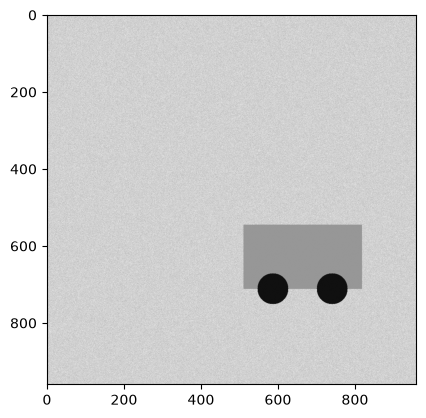

In [4]:
path = os.path.join(train_path, 'cars')
for img in os.listdir(path):
    img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
    plt.imshow(img_array, cmap='gray')
    plt.show()
    break

In [5]:
img_array.shape

(960, 960)

In [6]:
print(img_array)

[[115 113 123 ... 119 127 124]
 [115 126 121 ... 115 125 118]
 [122 131 124 ... 129 115 115]
 ...
 [112 124 120 ... 117 130 126]
 [126 124 129 ... 125 123 116]
 [125 118 128 ... 129 134 124]]


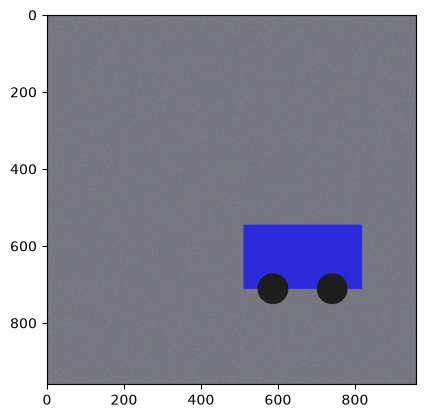

In [7]:
path = os.path.join(train_path, 'cars')
for img in os.listdir(path):
    img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_COLOR)
    plt.imshow(img_array)
    plt.show()
    break

In [8]:
img_array.shape

(960, 960, 3)

In [9]:
batch_size = 5
img_height = img_width = 180

In [10]:
train_ds = tf.keras.utils.image_dataset_from_directory(train_path,
                                                        image_size=(img_height, img_width),
                                                        label_mode = 'int',
                                                        validation_split = 0.2,
                                                        subset = "training",
                                                        color_mode = 'rgb',
                                                        seed = 2021,
                                                        batch_size = batch_size)

Found 12 files belonging to 2 classes.
Using 10 files for training.


2026-09-01 21:24:01.316978: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-09-01 21:24:01.317132: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-09-01 21:24:01.317139: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.00 GB
I0000 00:00:1788278041.317691 2976697 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1788278041.317816 2976697 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [11]:
val_ds = tf.keras.utils.image_dataset_from_directory(train_path,
                                                      image_size=(img_height, img_width),
                                                      label_mode = 'int',
                                                      validation_split = 0.2,
                                                      subset = "validation",
                                                      color_mode = 'rgb',
                                                      seed = 2021,
                                                      batch_size = batch_size)

Found 12 files belonging to 2 classes.
Using 2 files for validation.


In [12]:
for image, label in train_ds:
    print(image.shape)
    print(label.shape)

(5, 180, 180, 3)
(5,)
(5, 180, 180, 3)
(5,)


2026-09-01 21:24:20.242392: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [13]:
class_names = train_ds.class_names
class_names

['bus', 'cars']

2026-09-01 21:24:39.559508: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


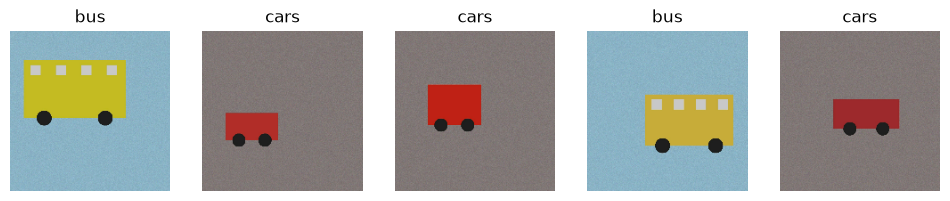

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 12))

for img, label in train_ds.take(1):
    for i in range(5):
        ax = plt.subplot(1, 5, i + 1)
        plt.imshow(img[i].numpy().astype("uint8"))
        plt.title(class_names[label[i]])
        plt.axis("off")

In [15]:
norm_layer = tf.keras.layers.Rescaling(scale=1./255)

In [16]:
normalized_ds = train_ds.map(lambda x, y: (norm_layer(x), y))
imgs, lbl = next(iter(normalized_ds))
first_img = imgs[0]
print(np.min(first_img), np.max(first_img))

0.018627452 0.8445527
